In [1]:
# ==============================
# WORKSHEET 6 - CNN + TRANSFER LEARNING
# Upload ZIP dataset and run all tasks
# ==============================

# STEP 1: Install / Import
import os, zipfile, shutil, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# STEP 2: Upload Dataset ZIP
from google.colab import files

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
extract_path = "uploaded_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Saving FruitinAmazon.zip to FruitinAmazon.zip
Dataset extracted successfully!


In [3]:
# STEP 3: Auto-find train folder

def find_train_folder(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if "train" in [d.lower() for d in dirnames]:
            for d in dirnames:
                if d.lower() == "train":
                    return os.path.join(dirpath, d)
    return root

train_dir = find_train_folder(extract_path)

print("Using training directory:", train_dir)
print("Folders/classes found:", os.listdir(train_dir))

Using training directory: uploaded_dataset/FruitinAmazon/train
Folders/classes found: ['tucuma', 'cupuacu', 'pupunha', 'guarana', 'acai', 'graviola']


In [4]:
# STEP 4: Verify Classes

class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print(f"Found {len(class_names)} classes:")
print(class_names)

Found 6 classes:
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [5]:
# STEP 5: Check corrupted images

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            with Image.open(img_path) as img:
                img.verify()
        except:
            corrupted_images.append(img_path)

print("Corrupted images found:", len(corrupted_images))

for img in corrupted_images:
    print(img)
    os.remove(img)

print("Corrupted images removed.")

Corrupted images found: 0
Corrupted images removed.


In [6]:
# STEP 6: Class balance count

class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))
    ]
    class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Image Count':>15}")
print("=" * 45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")

print("=" * 45)


Class Distribution:
Class Name                   Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


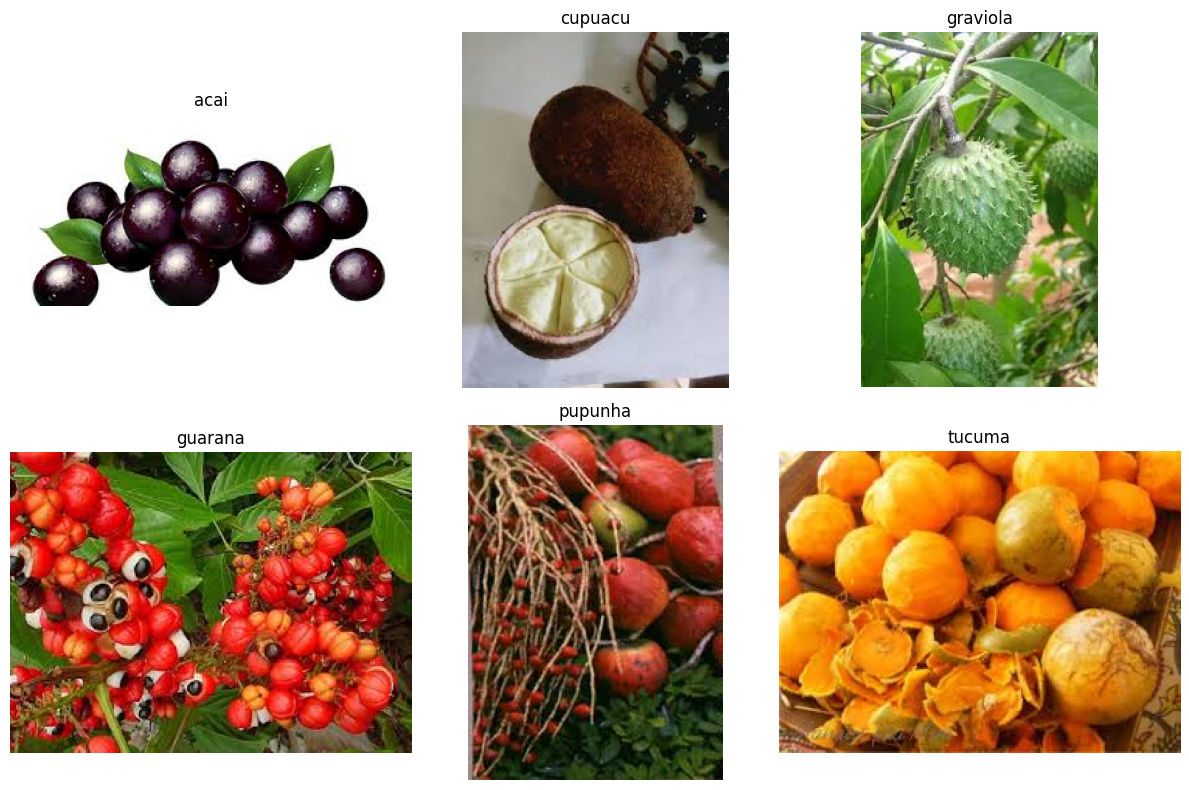

In [7]:
# STEP 7: Visualize one random image from each class

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))
    ]

    if images:
        selected_img = os.path.join(class_path, random.choice(images))
        selected_images.append(selected_img)
        selected_labels.append(class_name)

cols = 3
rows = int(np.ceil(len(selected_images) / cols))

plt.figure(figsize=(12, rows * 4))

for i, img_path in enumerate(selected_images):
    img = Image.open(img_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# STEP 8: Create train and validation dataset

image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [9]:
# STEP 9: Improve performance using prefetch

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

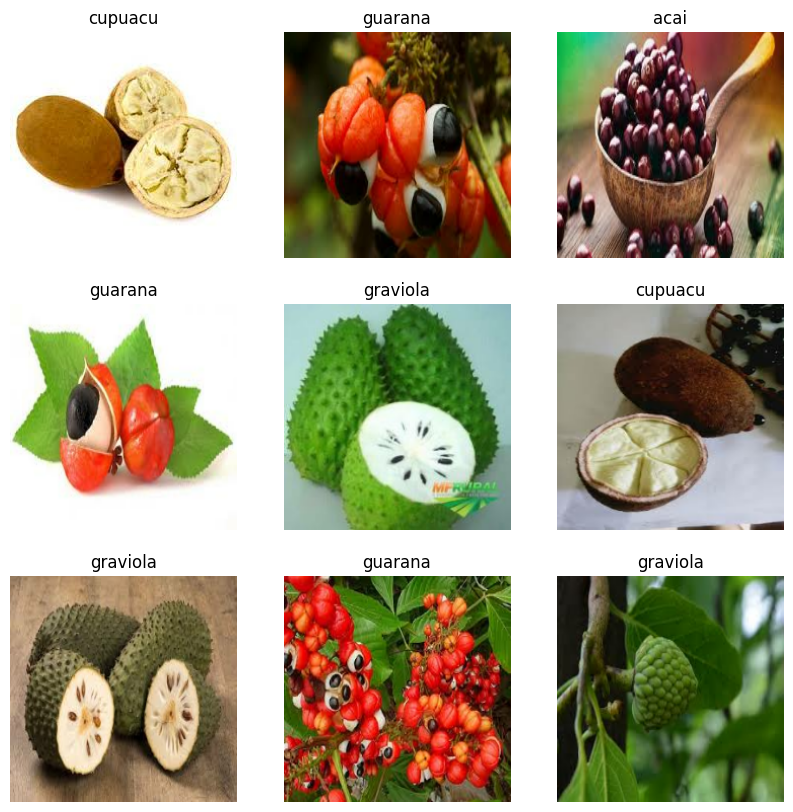

In [10]:
# STEP 10: Visualize training images

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

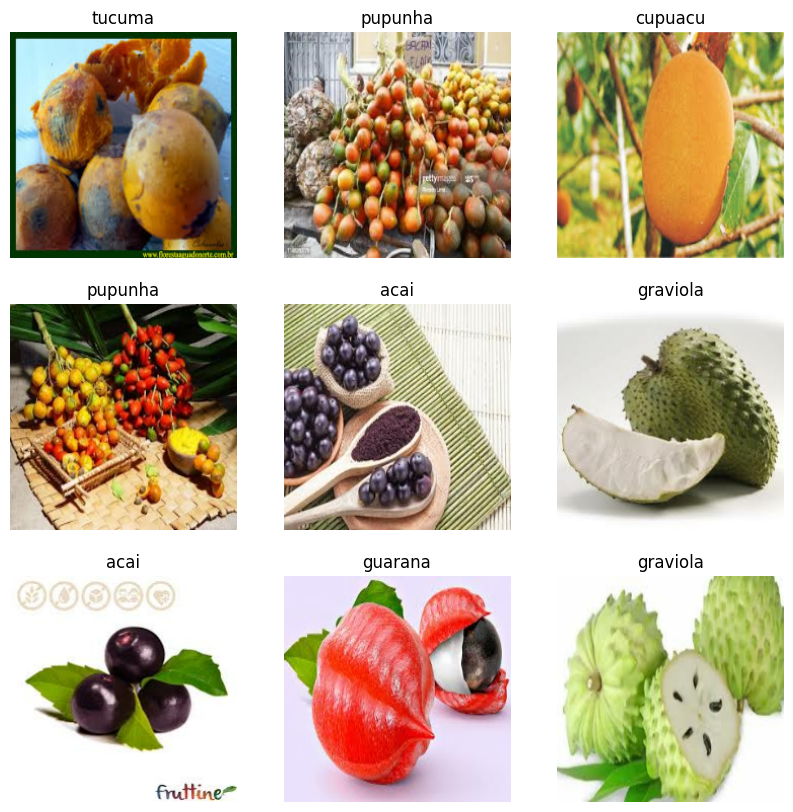

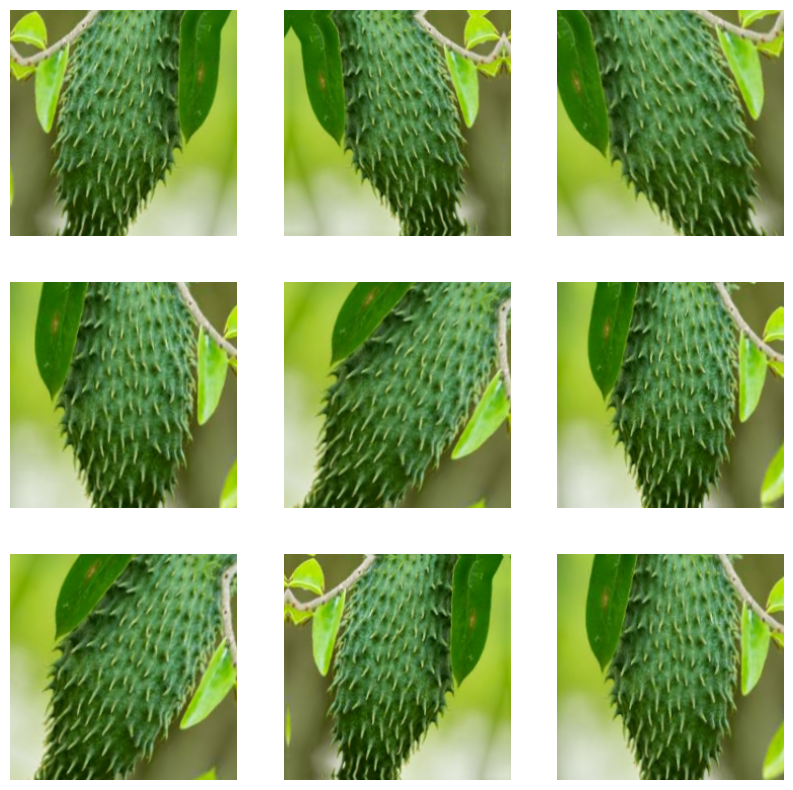

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,54

 Total params: 25,787,078 (98.37 MB)

 Trainable params: 25,786,118 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.1528 - loss: 2.5545 - val_accuracy: 0.1667 - val_loss: 2.1890
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.5139 - loss: 1.2852 - val_accuracy: 0.0556 - val_loss: 2.1072
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.6667 - loss: 0.9666 - val_accuracy: 0.2222 - val_loss: 1.8217
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.7083 - loss: 0.8646 - val_accuracy: 0.2222 - val_loss: 1.7567
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.7778 - loss: 0.6079 - val_accuracy: 0.2778 - val_loss: 1.7562
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.7222 - loss: 0.7880 - val_accuracy: 0.2222 - val_loss: 1.7520
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.7778 - loss: 0.5854 - val_accuracy: 0.2222 - val_loss: 1.7888
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.7778 - loss: 0.6126 - val_accuracy: 0.2222 - val_loss: 1.8387
Epoch 9/

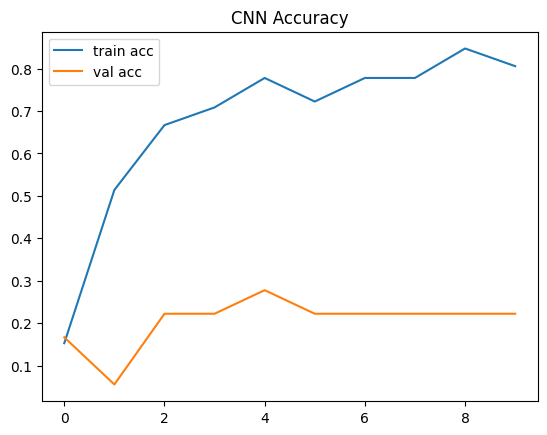

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step - accuracy: 0.2222 - loss: 2.0355
CNN Accuracy: 0.2222222238779068
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.22      1.00      0.36         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.22        18
   macro avg       0.04      0.17      0.06        18
weighted avg       0.05      0.22      0.08        18

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10


In [ ]:
# ==============================
# STEP 10: Visualize Training Images
# ==============================

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.show()


# ==============================
# STEP 11: Data Augmentation
# ==============================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])


# ==============================
# STEP 12: Visualize Augmented Images (FIXED)
# ==============================

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    first_image = images[0]

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0),
            training=True
        )

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")

plt.show()


# ==============================
# STEP 13: CNN MODEL (FROM SCRATCH)
# ==============================

num_classes = len(class_names)

cnn_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


# ==============================
# STEP 14: Train CNN
# ==============================

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


# ==============================
# STEP 15: Plot CNN Results
# ==============================

plt.plot(cnn_history.history["accuracy"], label="train acc")
plt.plot(cnn_history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("CNN Accuracy")
plt.show()


# ==============================
# STEP 16: Evaluate CNN
# ==============================

cnn_loss, cnn_acc = cnn_model.evaluate(val_ds)
print("CNN Accuracy:", cnn_acc)


# ==============================
# STEP 17: Classification Report (CNN)
# ==============================

from sklearn.metrics import classification_report

y_true, y_pred = [], []

for images, labels in val_ds:
    preds = cnn_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))


# ==============================
# STEP 18: TRANSFER LEARNING (VGG16)
# ==============================

from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False


# ==============================
# STEP 19: Build VGG Model
# ==============================

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

vgg_model = keras.Model(inputs, outputs)

vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()


# ==============================
# STEP 20: Train VGG16
# ==============================

vgg_history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


# ==============================
# STEP 21: Evaluate VGG16
# ==============================

vgg_loss, vgg_acc = vgg_model.evaluate(val_ds)
print("VGG16 Accuracy:", vgg_acc)


# ==============================
# STEP 22: Compare Results
# ==============================

print("\nFINAL COMPARISON")
print("===================")
print("CNN Accuracy:", cnn_acc)
print("VGG16 Accuracy:", vgg_acc)

if vgg_acc > cnn_acc:
    print("Transfer Learning is better")
else:
    print("CNN from scratch is better or similar")